使用デバイス: cuda
評価対象: ノンジャンル (ID: 9801)
SPMモデルロード完了 (Vocab Size: 16139)
各クラスのデータ数（バランス前）: エタり=20174, 完結=101124
→ 20174件ずつに揃えます
学習データ数: 32278, 評価(テスト)データ数: 8070
モデルロード完了: result_subword\model_9801.pt
評価を実行中...


C:\Users\blast\AppData\Local\Temp\ipykernel_30512\3828288593.py:209: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(final_model_path, map_loc


ノンジャンル
正解率 (Accuracy) : 0.6366
Classification Report:
              precision    recall  f1-score   support

          完結      0.613     0.742     0.671      4035
         エタる      0.673     0.531     0.594      4035

    accuracy                          0.637      8070
   macro avg      0.643     0.637     0.632      8070
weighted avg      0.643     0.637     0.632      8070



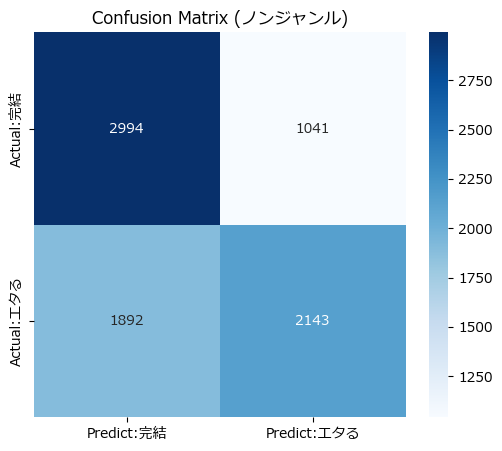

In [1]:
# --- ライブラリのインポート ---
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import sentencepiece as spm
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 日本語フォント設定
plt.rcParams['font.family'] = 'Meiryo'

# デバイス設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用デバイス: {device}")

# ==========================================
# ★設定
# ==========================================
TARGET_GENRE_ID = 9801

# ★学習コードと同じパラメータ設定
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 1
PADDING_IDX = 0 
BATCH_SIZE = 64

# パス設定
CSV_PATH = 'dataset/narou_dataset.csv'
RESULT_DIR = 'result_subword'

# ==========================================
# クラス定義 (train_subword.ipynb と一致)
# ==========================================

# 1. Datasetクラス
class NarouDataset(Dataset):
    def __init__(self, texts, labels, sp_model):
        self.texts = texts
        self.labels = labels
        self.sp_model = sp_model

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # inputはPandas Seriesであることを前提に .iloc を使用
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]
        token_ids = self.sp_model.EncodeAsIds(text)
        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(label, dtype=torch.float)

# 2. collate_fn
def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=PADDING_IDX)
    labels = torch.stack(labels)
    return texts_padded, labels

# 3. モデルクラス
class LSTMAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, padding_idx):
        super(LSTMAttentionClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        # Attention用の層
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, text):
        embedded = self.embedding(text)
        lstm_out, _ = self.lstm(embedded)
        
        # Attentionスコアの計算
        attn_weights = torch.tanh(self.attention(lstm_out)) 
        attn_weights = torch.softmax(attn_weights, dim=1) 
        
        # 重み付き和を計算
        context = torch.sum(attn_weights * lstm_out, dim=1) 
        
        return self.sigmoid(self.fc(context))

# ==========================================
# データ前処理関数 (学習コードと一致)
# ==========================================
def clean_text(text):
    text = str(text)
    # URLを <URL> に置換
    text = re.sub(r'https?://[\w/:%#\$&\?\(\)~\.=\+\-]+', '<URL>', text)
    # 改行コードをスペースに
    text = text.replace('\n', ' ').replace('\r', '')
    return text

# ==========================================
# 実行処理
# ==========================================

def evaluate_model():
    # ジャンル名解決
    genres_map = {
        0: '未設定', 101: '異世界（恋愛）', 102: '現実世界（恋愛）',
        201: 'ハイファンタジー', 202: 'ローファンタジー',
        301: '純文学', 302: 'ヒューマンドラマ', 303: '歴史',
        304: '推理', 305: 'ホラー', 306: 'アクション', 307: 'コメディー',
        401: 'VRゲーム', 402: '宇宙', 403: '空想科学', 404: 'パニック',
        9901: '童話', 9902: '詩', 9903: 'エッセイ', 9904: 'リプレイ',
        9999: 'その他', 9801: 'ノンジャンル'
    }

    if TARGET_GENRE_ID is None:
        suffix = 'all'
        genre_name = '全作品(All)'
    else:
        suffix = str(TARGET_GENRE_ID)
        genre_name = genres_map.get(TARGET_GENRE_ID, 'Unknown')

    print(f"評価対象: {genre_name} (ID: {suffix})")

    model_path = os.path.join(RESULT_DIR, f'model_{suffix}.pt')
    spm_path = os.path.join(RESULT_DIR, f'spm_{suffix}.model')

    # 1. SPMモデルのロード
    if not os.path.exists(spm_path):
        raise FileNotFoundError(f"SPMモデルが見つかりません: {spm_path}")
    
    sp = spm.SentencePieceProcessor()
    sp.Load(spm_path)
    vocab_size = sp.GetPieceSize()
    print(f"SPMモデルロード完了 (Vocab Size: {vocab_size})")

    # 2. データの読み込み
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"データセットが見つかりません: {CSV_PATH}")
        
    try:
        df = pd.read_csv(CSV_PATH, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(CSV_PATH, encoding='cp932')

    # --- 学習コードと同じデータ構築フロー ---
    
    # ジャンルフィルタリング
    if TARGET_GENRE_ID is not None:
        df['作品ジャンル'] = pd.to_numeric(df['作品ジャンル'], errors='coerce')
        df = df[df['作品ジャンル'] == TARGET_GENRE_ID]
        if len(df) == 0:
            print("該当するジャンルのデータが存在しません。")
            return

    # 必要なカラムのみ抽出
    df = df[['あらすじ', 'is_eternal']].dropna()
    
    # テキスト前処理
    df['あらすじ'] = df['あらすじ'].apply(clean_text)

    # アンダーサンプリング
    eternal_df = df[df['is_eternal'] == 1]
    finished_df = df[df['is_eternal'] == 0]

    min_count = min(len(eternal_df), len(finished_df))
    print(f"各クラスのデータ数（バランス前）: エタり={len(eternal_df)}, 完結={len(finished_df)}")
    print(f"→ {min_count}件ずつに揃えます")

    # ランダムサンプリング (学習時と同じrandom_state=42)
    eternal_balanced = eternal_df.sample(n=min_count, random_state=42)
    finished_balanced = finished_df.sample(n=min_count, random_state=42)

    # 結合してシャッフル (学習時と同じrandom_state=42)
    df_balanced = pd.concat([eternal_balanced, finished_balanced])
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

    # 学習用とテスト用に分割 (学習時と同じrandom_state=42)
    # これにより、test_df は学習時に使用された「テストデータ」と同一のものになります
    train_df, test_df = train_test_split(
        df_balanced, 
        test_size=0.2, 
        random_state=42, 
        stratify=df_balanced['is_eternal']
    )

    print(f"学習データ数: {len(train_df)}, 評価(テスト)データ数: {len(test_df)}")

    # インデックスのリセット (Datasetでの参照ズレ防止)
    test_df = test_df.reset_index(drop=True)

    # DataLoader作成
    test_dataset = NarouDataset(test_df['あらすじ'], test_df['is_eternal'], sp)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    # 4. モデルのロード
    if not os.path.exists(model_path):
        alt_path = model_path.replace('.pt', '.pth')
        if os.path.exists(alt_path):
            final_model_path = alt_path
        else:
            raise FileNotFoundError(f"モデルファイルが見つかりません: {model_path}")
    else:
        final_model_path = model_path

    model = LSTMAttentionClassifier(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, PADDING_IDX)
    model.load_state_dict(torch.load(final_model_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"モデルロード完了: {final_model_path}")

    # 5. 推論実行
    y_true_list = []
    y_pred_list = []
    
    print("評価を実行中...")
    with torch.no_grad():
        for texts, labels in test_loader:
            texts = texts.to(device)
            labels = labels.to(device)
            
            outputs = model(texts).squeeze(1)
            preds = (outputs >= 0.5).long()
            
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 6. 結果表示
    acc = accuracy_score(y_true_list, y_pred_list)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true_list, y_pred_list, average='binary')

    print("\n" + "="*30)
    print(genre_name)
    print("="*30)
    print(f"正解率 (Accuracy) : {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_true_list, y_pred_list, target_names=['完結', 'エタる'],digits=3))

    cm = confusion_matrix(y_true_list, y_pred_list)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predict:完結', 'Predict:エタる'], 
                yticklabels=['Actual:完結', 'Actual:エタる'])
    plt.title(f'Confusion Matrix ({genre_name})')
    plt.show()

if __name__ == "__main__":
    evaluate_model()